Read Parquet from Azure Data Lake and Save CSV in CSV Folder

In [ ]:
from pyspark.sql import SparkSession
import os

# Start Spark session for reading Parquet files from Azure and exporting single CSV files
tezz_spark = SparkSession.builder \
    .appName("Tezz Azure Parquet to Single CSV Export") \
    .config(
        "spark.jars.packages",
        "org.apache.hadoop:hadoop-azure:3.3.6,com.microsoft.azure:azure-storage:8.6.6"
    ) \
    .getOrCreate()

# Store Azure Storage account and container information
tezz_storage_account = "bigdatastoragelake"
tezz_container_name = "nyc"

# Add SAS token without the starting question mark
# This token must include read, write, create, delete, and list permissions
tezz_sas_token = "YOUR_SAS_TOKEN"

# Connect Spark with Azure Blob/Data Lake through SAS authentication
tezz_spark.conf.set(
    f"fs.azure.sas.{tezz_container_name}.{tezz_storage_account}.blob.core.windows.net",
    tezz_sas_token
)

# Define the source Parquet files stored in Azure container root
tezz_input_files = [
    f"wasbs://{tezz_container_name}@{tezz_storage_account}.blob.core.windows.net/yellow_tripdata_2025-09.parquet",
    f"wasbs://{tezz_container_name}@{tezz_storage_account}.blob.core.windows.net/yellow_tripdata_2025-10.parquet",
    f"wasbs://{tezz_container_name}@{tezz_storage_account}.blob.core.windows.net/yellow_tripdata_2025-11.parquet",
    f"wasbs://{tezz_container_name}@{tezz_storage_account}.blob.core.windows.net/yellow_tripdata_2025-12.parquet"
]

# Set final CSV folder path in Azure
tezz_csv_folder_path = (
    f"wasbs://{tezz_container_name}@{tezz_storage_account}.blob.core.windows.net/csv"
)

# Convert every Parquet file into one clearly named CSV file inside the csv folder
for tezz_file_path in tezz_input_files:

    # Extract original file name and replace .parquet with .csv
    tezz_file_name = os.path.basename(tezz_file_path).replace(".parquet", ".csv")

    # Temporary folder where Spark first writes the CSV part file
    tezz_temp_output_path = (
        f"wasbs://{tezz_container_name}@{tezz_storage_account}.blob.core.windows.net/"
        f"temp_{tezz_file_name}"
    )

    # Final single CSV file path inside the csv folder
    tezz_final_csv_path = f"{tezz_csv_folder_path}/{tezz_file_name}"

    # Read the Parquet file from Azure
    tezz_dataframe = tezz_spark.read.parquet(tezz_file_path)

    # Write data into one temporary CSV part file
    tezz_dataframe.coalesce(1).write \
        .mode("overwrite") \
        .option("header", "true") \
        .csv(tezz_temp_output_path)

    # Get all files from the temporary Spark output folder
    tezz_temp_files = dbutils.fs.ls(tezz_temp_output_path)

    # Find the generated CSV part file
    tezz_generated_csv_file = [
        tezz_file.path
        for tezz_file in tezz_temp_files
        if tezz_file.path.endswith(".csv")
    ][0]

    # Move and rename the generated CSV file into the csv folder
    dbutils.fs.mv(tezz_generated_csv_file, tezz_final_csv_path)

    # Remove the temporary folder after final file is saved
    dbutils.fs.rm(tezz_temp_output_path, recurse=True)

    print(f"Single CSV file saved successfully at: {tezz_final_csv_path}")

Single CSV file saved successfully at: wasbs://nyc@bigdatastoragelake.blob.core.windows.net/csv/yellow_tripdata_2025-09.csv
Single CSV file saved successfully at: wasbs://nyc@bigdatastoragelake.blob.core.windows.net/csv/yellow_tripdata_2025-10.csv
Single CSV file saved successfully at: wasbs://nyc@bigdatastoragelake.blob.core.windows.net/csv/yellow_tripdata_2025-11.csv
Single CSV file saved successfully at: wasbs://nyc@bigdatastoragelake.blob.core.windows.net/csv/yellow_tripdata_2025-12.csv


Azure Data Lake CSV Preprocessing and Cleaned Output Export

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, unix_timestamp, hour, dayofweek, month
import os

# Start Spark session for reading CSV files from Azure and saving cleaned CSV files
tezz_spark = SparkSession.builder \
    .appName("Tezz Azure CSV Preprocessing") \
    .config(
        "spark.jars.packages",
        "org.apache.hadoop:hadoop-azure:3.3.6,com.microsoft.azure:azure-storage:8.6.6"
    ) \
    .getOrCreate()

# Store Azure Storage account and container information
tezz_storage_account = "bigdatastoragelake"
tezz_container_name = "nyc"

# Add SAS token without the starting question mark
# This token must include read, write, create, delete, and list permissions
tezz_sas_token = "YOUR_SAS_TOKEN"

# Connect Spark with Azure Blob/Data Lake through SAS authentication
tezz_spark.conf.set(
    f"fs.azure.sas.{tezz_container_name}.{tezz_storage_account}.blob.core.windows.net",
    tezz_sas_token
)

# Define Azure folder paths
tezz_base_path = (
    f"wasbs://{tezz_container_name}@{tezz_storage_account}.blob.core.windows.net"
)

tezz_input_folder_path = f"{tezz_base_path}/csv"
tezz_clean_output_folder_path = f"{tezz_base_path}/clean_data"

# Define CSV files to clean from the csv folder
tezz_input_files = [
    "yellow_tripdata_2025-09.csv",
    "yellow_tripdata_2025-10.csv",
    "yellow_tripdata_2025-11.csv",
    "yellow_tripdata_2025-12.csv"
]

# Clean every CSV file and save it as a single file with the same name inside clean_data folder
for tezz_file_name in tezz_input_files:

    try:
        # Build full source CSV file path
        tezz_file_path = f"{tezz_input_folder_path}/{tezz_file_name}"

        # Temporary folder where Spark writes the cleaned CSV part file first
        tezz_temp_output_path = f"{tezz_base_path}/temp_clean_{tezz_file_name}"

        # Final cleaned CSV file path with the same original file name
        tezz_final_clean_file_path = f"{tezz_clean_output_folder_path}/{tezz_file_name}"

        print(f"\nReading CSV file from Azure: {tezz_file_name}")

        # Read CSV file with column headers and automatic schema detection
        tezz_month_df = tezz_spark.read \
            .option("header", "true") \
            .option("inferSchema", "true") \
            .csv(tezz_file_path)

        # Store original row and column counts before preprocessing
        tezz_original_rows = tezz_month_df.count()
        tezz_original_columns = len(tezz_month_df.columns)

        print("Original Dataset Information")
        print(f"Rows Before Cleaning: {tezz_original_rows}")
        print(f"Columns: {tezz_original_columns}")

        # Remove duplicate records to keep each taxi trip only once
        tezz_clean_df = tezz_month_df.dropDuplicates()

        # Remove records where key trip fields are missing
        tezz_clean_df = tezz_clean_df.dropna(subset=[
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "trip_distance",
            "fare_amount",
            "total_amount",
            "passenger_count",
            "PULocationID",
            "DOLocationID"
        ])

        # Keep only valid numeric trip records for clean analysis
        tezz_clean_df = tezz_clean_df.filter(col("trip_distance") > 0)
        tezz_clean_df = tezz_clean_df.filter(col("fare_amount") > 0)
        tezz_clean_df = tezz_clean_df.filter(col("total_amount") > 0)
        tezz_clean_df = tezz_clean_df.filter(col("passenger_count") > 0)

        # Calculate trip duration in minutes from pickup and drop-off timestamps
        tezz_clean_df = tezz_clean_df.withColumn(
            "trip_duration_minutes",
            (
                unix_timestamp(col("tpep_dropoff_datetime"))
                -
                unix_timestamp(col("tpep_pickup_datetime"))
            ) / 60
        )

        # Remove records with impossible or zero trip duration
        tezz_clean_df = tezz_clean_df.filter(col("trip_duration_minutes") > 0)

        # Create time-based features for later data analysis and visualisation
        tezz_clean_df = tezz_clean_df.withColumn(
            "pickup_hour",
            hour(col("tpep_pickup_datetime"))
        )

        tezz_clean_df = tezz_clean_df.withColumn(
            "pickup_day",
            dayofweek(col("tpep_pickup_datetime"))
        )

        tezz_clean_df = tezz_clean_df.withColumn(
            "pickup_month",
            month(col("tpep_pickup_datetime"))
        )

        # Save cleaned data into one temporary CSV part file
        tezz_clean_df.coalesce(1).write \
            .mode("overwrite") \
            .option("header", "true") \
            .csv(tezz_temp_output_path)

        # Locate the CSV part file created by Spark
        tezz_temp_files = dbutils.fs.ls(tezz_temp_output_path)

        tezz_generated_clean_csv_file = [
            tezz_file.path
            for tezz_file in tezz_temp_files
            if tezz_file.path.endswith(".csv")
        ][0]

        # Move and rename the cleaned CSV file into clean_data folder using same file name
        dbutils.fs.mv(tezz_generated_clean_csv_file, tezz_final_clean_file_path)

        # Delete temporary Spark output folder after moving the final file
        dbutils.fs.rm(tezz_temp_output_path, recurse=True)

        # Count final rows after preprocessing
        tezz_final_rows = tezz_clean_df.count()

        print("\nPreprocessing Summary")
        print(f"Processed File: {tezz_file_name}")
        print(f"Rows Before Cleaning: {tezz_original_rows}")
        print(f"Rows After Cleaning: {tezz_final_rows}")
        print(f"Removed Rows: {tezz_original_rows - tezz_final_rows}")
        print(f"Cleaned File Saved At: {tezz_final_clean_file_path}")

        print("\nSample Cleaned Data")
        tezz_clean_df.show(5, truncate=False)

    except Exception as tezz_error:
        print(f"\nPreprocessing Failed For: {tezz_file_name}")
        print("Error Details:")
        print(tezz_error)

# Display all cleaned files saved inside clean_data folder
print("\nAll selected CSV files have been cleaned successfully.")

display(
    dbutils.fs.ls(tezz_clean_output_folder_path)
)


Reading CSV file from Azure: yellow_tripdata_2025-09.csv
Original Dataset Information
Rows Before Cleaning: 4251015
Columns: 20

Preprocessing Summary
Processed File: yellow_tripdata_2025-09.csv
Rows Before Cleaning: 4251015
Rows After Cleaning: 2989328
Removed Rows: 1261687
Cleaned File Saved At: wasbs://nyc@bigdatastoragelake.blob.core.windows.net/clean_data/yellow_tripdata_2025-09.csv

Sample Cleaned Data
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+---------------------+-----------+----------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|co

path,name,size,modificationTime
wasbs://nyc@bigdatastoragelake.blob.core.windows.net/clean_data/yellow_tripdata_2025-09.csv,yellow_tripdata_2025-09.csv,411283311,1779628431000
wasbs://nyc@bigdatastoragelake.blob.core.windows.net/clean_data/yellow_tripdata_2025-10.csv,yellow_tripdata_2025-10.csv,449004800,1779628505000
wasbs://nyc@bigdatastoragelake.blob.core.windows.net/clean_data/yellow_tripdata_2025-11.csv,yellow_tripdata_2025-11.csv,415867684,1779628574000
wasbs://nyc@bigdatastoragelake.blob.core.windows.net/clean_data/yellow_tripdata_2025-12.csv,yellow_tripdata_2025-12.csv,408199045,1779628644000


Describe Cleaned NYC Taxi Datasets from Azure clean_data Folder

In [ ]:
# ============================================================
# DESCRIBE CLEANED NYC TAXI DATASETS FROM AZURE DATA LAKE
# This code reads cleaned CSV files and shows dataset details
# ============================================================

from pyspark.sql.functions import col

# Define the cleaned CSV files saved inside clean_data folder
tezz_clean_files = [
    "yellow_tripdata_2025-09.csv",
    "yellow_tripdata_2025-10.csv",
    "yellow_tripdata_2025-11.csv",
    "yellow_tripdata_2025-12.csv"
]

# Loop through each cleaned CSV file and describe its structure
for tezz_file_name in tezz_clean_files:

    print("\n" + "=" * 80)
    print(f"DATASET DESCRIPTION FOR: {tezz_file_name}")
    print("=" * 80)

    # Create full path of the cleaned CSV file
    tezz_clean_file_path = f"{tezz_clean_output_folder_path}/{tezz_file_name}"

    # Read cleaned CSV file from Azure clean_data folder
    tezz_clean_df = tezz_spark.read \
        .option("header", "true") \
        .option("inferSchema", "true") \
        .csv(tezz_clean_file_path)

    # Show number of rows and columns
    tezz_total_rows = tezz_clean_df.count()
    tezz_total_columns = len(tezz_clean_df.columns)

    print(f"Total Rows: {tezz_total_rows}")
    print(f"Total Columns: {tezz_total_columns}")

    # Display column names
    print("\nColumn Names:")
    for tezz_column_name in tezz_clean_df.columns:
        print(f"- {tezz_column_name}")

    # Display schema with column data types
    print("\nDataset Schema:")
    tezz_clean_df.printSchema()

    # Show summary statistics for numeric columns
    print("\nNumerical Summary Statistics:")
    tezz_clean_df.describe().show(truncate=False)

    # Show missing value count for each column
    print("\nMissing Values Per Column:")
    tezz_missing_values = tezz_clean_df.select([
        col(tezz_column_name).isNull().cast("int").alias(tezz_column_name)
        for tezz_column_name in tezz_clean_df.columns
    ])

    tezz_missing_values_summary = tezz_missing_values.groupBy().sum()

    tezz_missing_values_summary.show(truncate=False)

    # Show first five rows for checking data format
    print("\nSample Records:")
    tezz_clean_df.show(5, truncate=False)


DATASET DESCRIPTION FOR: yellow_tripdata_2025-09.csv
Total Rows: 2989328
Total Columns: 24

Column Names:
- VendorID
- tpep_pickup_datetime
- tpep_dropoff_datetime
- passenger_count
- trip_distance
- RatecodeID
- store_and_fwd_flag
- PULocationID
- DOLocationID
- payment_type
- fare_amount
- extra
- mta_tax
- tip_amount
- tolls_amount
- improvement_surcharge
- total_amount
- congestion_surcharge
- Airport_fee
- cbd_congestion_fee
- trip_duration_minutes
- pickup_hour
- pickup_day
- pickup_month

Dataset Schema:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: integer (nullable = true)
 |--

In [ ]:
from pyspark.sql.functions import col, count, avg, round, desc
import matplotlib.pyplot as plt


Trip Demand by Pickup Hour

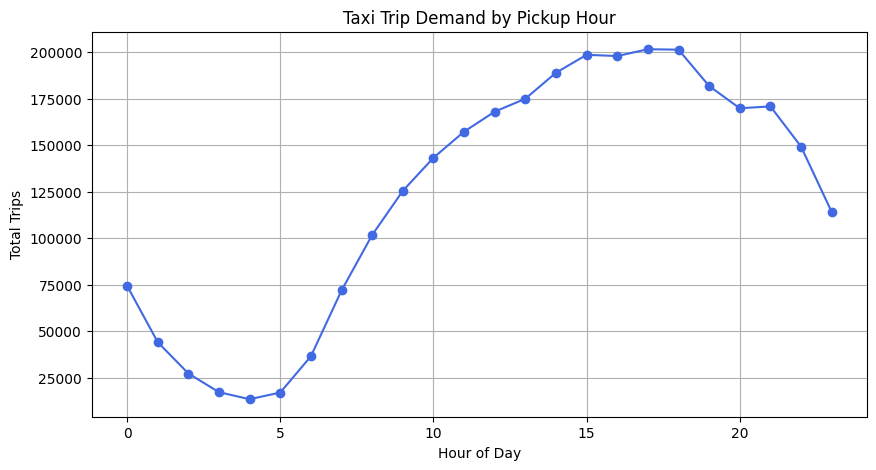

In [ ]:
tezz_hour_analysis = tezz_clean_df.groupBy("pickup_hour") \
    .agg(count("*").alias("total_trips")) \
    .orderBy("pickup_hour") \
    .toPandas()

plt.figure(figsize=(10, 5))
plt.plot(tezz_hour_analysis["pickup_hour"], tezz_hour_analysis["total_trips"], marker="o", color="royalblue")
plt.title("Taxi Trip Demand by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Trips")
plt.grid(True)
plt.show()

Trip Demand by Day of Week

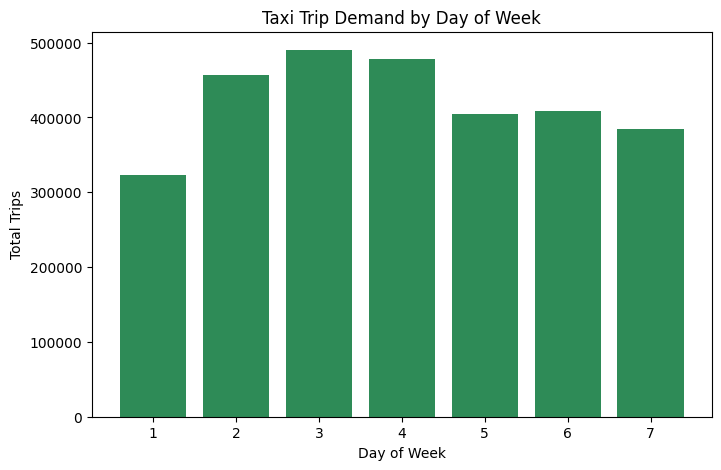

In [ ]:
tezz_day_analysis = tezz_clean_df.groupBy("pickup_day") \
    .agg(count("*").alias("total_trips")) \
    .orderBy("pickup_day") \
    .toPandas()

plt.figure(figsize=(8, 5))
plt.bar(tezz_day_analysis["pickup_day"].astype(str), tezz_day_analysis["total_trips"], color="seagreen")
plt.title("Taxi Trip Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Trips")
plt.show()

Monthly Trip Trend

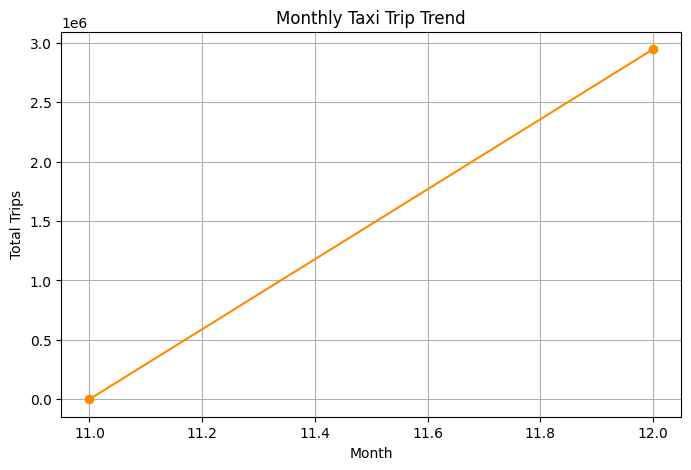

In [ ]:
tezz_month_analysis = tezz_clean_df.groupBy("pickup_month") \
    .agg(count("*").alias("total_trips")) \
    .orderBy("pickup_month") \
    .toPandas()

plt.figure(figsize=(8, 5))
plt.plot(tezz_month_analysis["pickup_month"], tezz_month_analysis["total_trips"], marker="o", color="darkorange")
plt.title("Monthly Taxi Trip Trend")
plt.xlabel("Month")
plt.ylabel("Total Trips")
plt.grid(True)
plt.show()

Top Pickup Locations

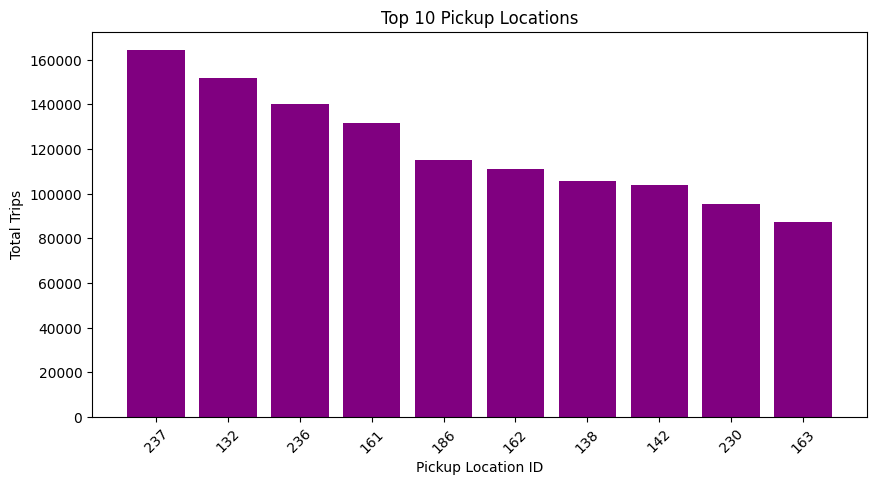

In [ ]:
tezz_pickup_analysis = tezz_clean_df.groupBy("PULocationID") \
    .agg(count("*").alias("total_trips")) \
    .orderBy(desc("total_trips")) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(10, 5))
plt.bar(tezz_pickup_analysis["PULocationID"].astype(str), tezz_pickup_analysis["total_trips"], color="purple")
plt.title("Top 10 Pickup Locations")
plt.xlabel("Pickup Location ID")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.show()

Top Drop-off Locations

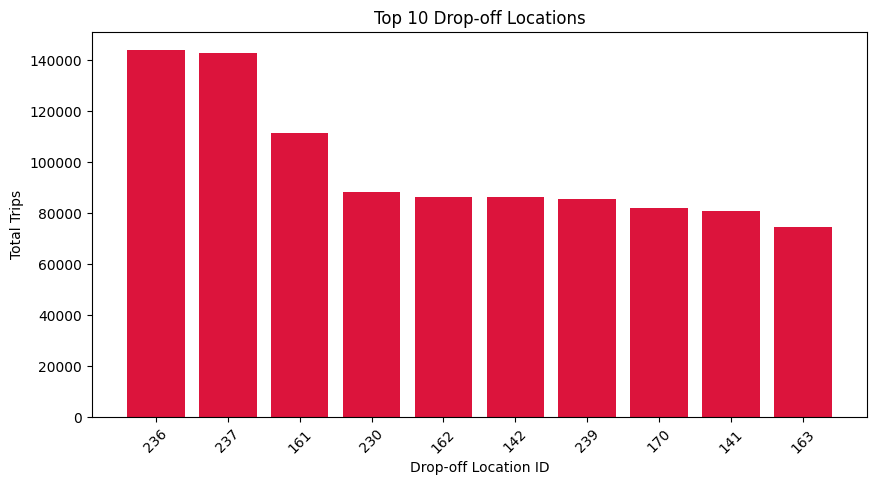

In [ ]:
tezz_dropoff_analysis = tezz_clean_df.groupBy("DOLocationID") \
    .agg(count("*").alias("total_trips")) \
    .orderBy(desc("total_trips")) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(10, 5))
plt.bar(tezz_dropoff_analysis["DOLocationID"].astype(str), tezz_dropoff_analysis["total_trips"], color="crimson")
plt.title("Top 10 Drop-off Locations")
plt.xlabel("Drop-off Location ID")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.show()

Payment Method Usage

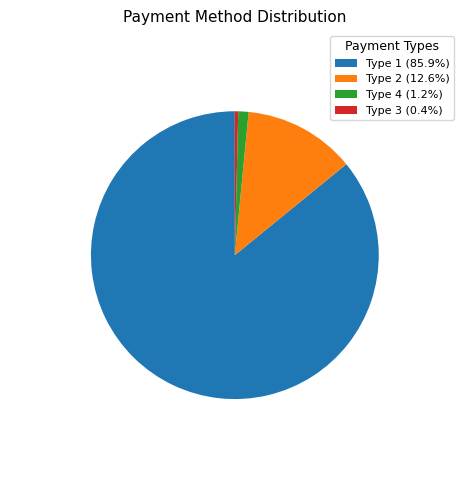

In [ ]:
tezz_payment_analysis = tezz_clean_df.groupBy("payment_type") \
    .agg(count("*").alias("total_trips")) \
    .orderBy(desc("total_trips")) \
    .toPandas()

# Calculate percentage values for legend labels
tezz_total_trips = tezz_payment_analysis["total_trips"].sum()

tezz_legend_labels = [
    f"Type {tezz_payment_analysis['payment_type'][i]} "
    f"({(tezz_payment_analysis['total_trips'][i] / tezz_total_trips) * 100:.1f}%)"
    for i in range(len(tezz_payment_analysis))
]

# Create smaller pie chart
plt.figure(figsize=(5, 5))

plt.pie(
    tezz_payment_analysis["total_trips"],
    startangle=90,
    radius=0.8
)

# Add compact legend
plt.legend(
    tezz_legend_labels,
    title="Payment Types",
    loc="upper right",
    fontsize=8,
    title_fontsize=9
)

plt.title("Payment Method Distribution", fontsize=11)
plt.tight_layout()
plt.show()

Average Fare by Pickup Hour

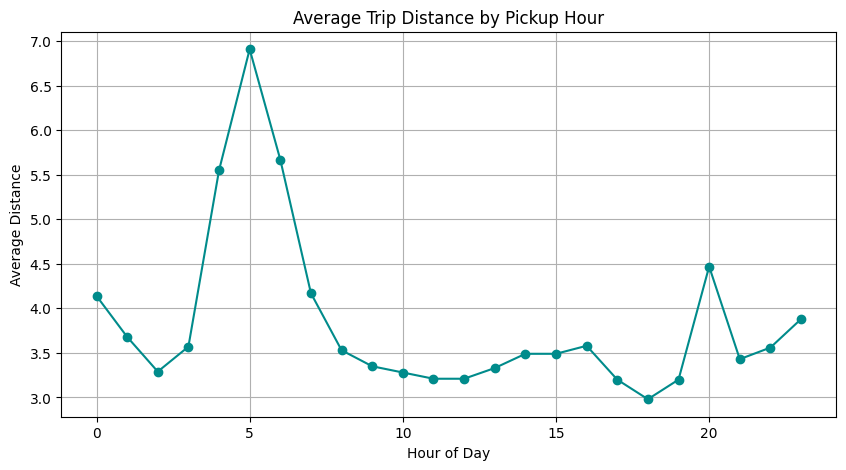

In [ ]:
tezz_distance_hour_analysis = tezz_clean_df.groupBy("pickup_hour") \
    .agg(round(avg("trip_distance"), 2).alias("average_distance")) \
    .orderBy("pickup_hour") \
    .toPandas()

plt.figure(figsize=(10, 5))
plt.plot(tezz_distance_hour_analysis["pickup_hour"], tezz_distance_hour_analysis["average_distance"], marker="o", color="darkcyan")
plt.title("Average Trip Distance by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Distance")
plt.grid(True)
plt.show()

Average Trip Duration by Hour

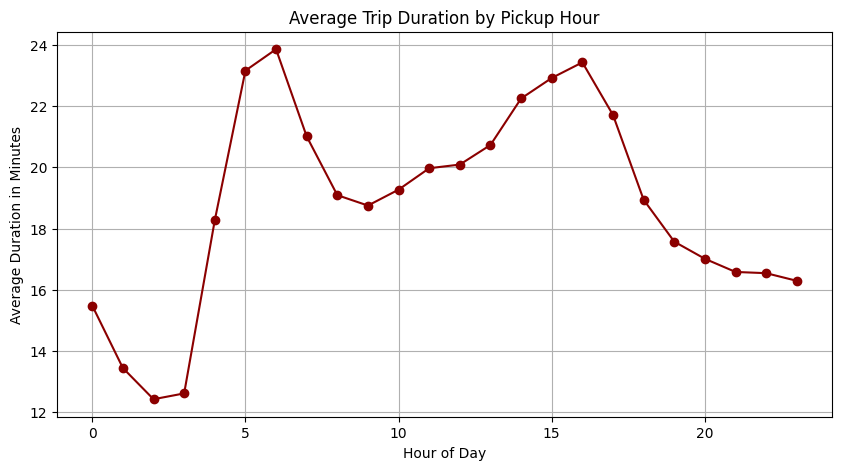

In [ ]:
tezz_duration_hour_analysis = tezz_clean_df.groupBy("pickup_hour") \
    .agg(round(avg("trip_duration_minutes"), 2).alias("average_duration")) \
    .orderBy("pickup_hour") \
    .toPandas()

plt.figure(figsize=(10, 5))
plt.plot(tezz_duration_hour_analysis["pickup_hour"], tezz_duration_hour_analysis["average_duration"], marker="o", color="darkred")
plt.title("Average Trip Duration by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Duration in Minutes")
plt.grid(True)
plt.show()

Tip Amount by Payment Type

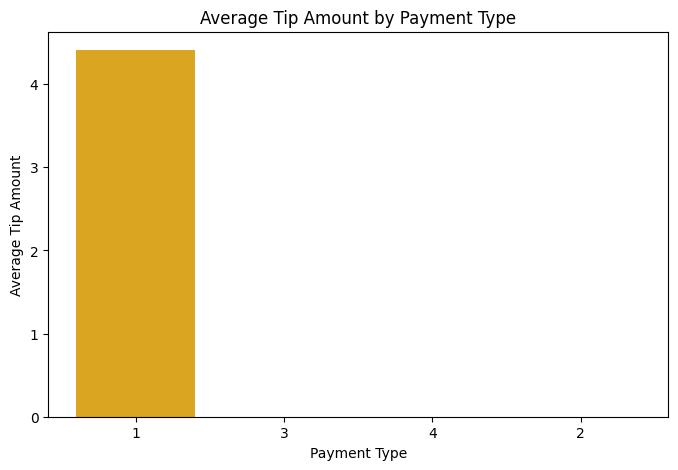

In [ ]:
tezz_tip_payment_analysis = tezz_clean_df.groupBy("payment_type") \
    .agg(round(avg("tip_amount"), 2).alias("average_tip")) \
    .orderBy(desc("average_tip")) \
    .toPandas()

plt.figure(figsize=(8, 5))
plt.bar(tezz_tip_payment_analysis["payment_type"].astype(str), tezz_tip_payment_analysis["average_tip"], color="goldenrod")
plt.title("Average Tip Amount by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Tip Amount")
plt.show()

# References

- Few, S. (2021) Show Me the Numbers: Designing Tables and Graphs to Enlighten. Burlingame: Analytics Press.
- Han, J., Pei, J. and Tong, H. (2022) Data Mining: Concepts and Techniques. 4th edn. Cambridge, MA: Morgan Kaufmann
  Karau, H., Konwinski, A., Wendell, P. and Zaharia, M. (2025) Learning Spark: Lightning-Fast Data Analytics. 3rd edn. Sebastopol: O’Reilly Media.
- McKinney, W. (2023) Python for Data Analysis. 3rd edn. Sebastopol: O’Reilly Media.
- Murray, S. (2023) Interactive Data Visualization for the Web. 3rd edn. Sebastopol: O’Reilly Media.
- Apache Spark Documentation (2026) Apache Spark Documentation. Accessed: 24 May 2026.
- Azure Blob Storage Documentation (2026) Azure Blob Storage Documentation. Accessed: 24 May 2026.
- Azure Data Lake Storage Documentation (2026) Azure Data Lake Storage Documentation. Accessed: 24 May 2026.
- Matplotlib Documentation (2026) Matplotlib Documentation. Accessed: 24 May 2026.
- Pandas Documentation (2026) Pandas Documentation. Accessed: 24 May 2026.